# Beam configuration from real data taking run
This notebook shows the beam configurations for real data taking during Run6

In [1]:
%load_ext autoreload
%autoreload 


In [2]:
import timeit
import copy
import concurrent.futures 
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import batoid

from ghosts import plotter
from ghosts import simulator
from ghosts import tweak_optics
from ghosts import beam
from ghosts import geom


from ghosts.analysis import compute_ghost_separations, reduce_ghosts
from ghosts.analysis import match_ghosts, compute_reduced_distance, compute_2d_reduced_distance, find_nearest_ghost
from ghosts.analysis import make_data_frame

from ghosts.beam_configs import BEAM_CONFIG_0, BEAM_CONFIG_1, BEAM_CONFIG_3
from ghosts.geom_configs import GEOM_CONFIG_0

from ghosts.camera import build_camera, show_camera

## Build a basic telescope for debugging

In [3]:
# A few numbers, sepcific to 600 nm
beam_power_600nm = 13  # 13 Watt for the full spot according to measurements done in Grenoble
ccd_reflectivity_600nm = 0.141338
ccd_qe_600nm = 0.843274
lens_reflectivity_600nm = 0.004  # 0.4% code by Julien Bolmont
filter_reflectivity_600nm = 0.038  # r band filter documentation stated transmission is 96.2%

# CCOB like geometry, i.e. lenses but no filter
telescope = batoid.Optic.fromYaml("../data/LSST_CCOB_r.yaml")

# Make refractive interfaces partially reflective
# Call on current telescope, smart coating is [lens, filter, camera]
tweak_optics.make_optics_reflective(telescope, coating='smart',
                                    r_frac=[lens_reflectivity_600nm, filter_reflectivity_600nm, ccd_reflectivity_600nm])

0

In [4]:
# Ray trace one config for debugging
trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=BEAM_CONFIG_1)
simulation = [trace_full, r_forward, r_reverse, rays]

# reduce ghosts
spots_data, _spots = reduce_ghosts(r_forward)
spots_data_frame = make_data_frame(spots_data)
gh_sep = compute_ghost_separations(spots_data_frame)

## Define a function to fully visualize a beam configuration and ghosts

In [5]:
def beam_test(telescope, beam_config):
    # Run simulation with standard beam config
    trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=beam_config)
    simulation = [trace_full, r_forward, r_reverse, rays]
    # Check setup
    #plotter.plot_setup(telescope, simulation)

    # camera and ghosts visualization
    spots_data, _spots = reduce_ghosts(r_forward)
    spots_data_frame = make_data_frame(spots_data)
    _fig, _ax = plotter.plot_full_camera_and_spots(r_forward, spots_data_frame, log_scale=True)
    camera = build_camera()
    show_camera(_ax[1], camera)

    # pixel signal
    plt.rcParams["figure.figsize"] = [15, 6]
    fig, ax = plt.subplots(1, 2)
    axs = ax.flatten()
    spots_data_frame["pixel_signal_log"] = np.log10(spots_data_frame["pixel_signal"])
    #spots_data_frame.plot.bar("name", "pixel_signal_log")
    names = [f'{s}' for s in list(spots_data_frame["name"])]
    ax[0].bar(names, spots_data_frame["pixel_signal_log"])
    ax[0].set_xlabel("Ghost")
    ax[0].set_label("log10(pixel_signal)")
    ax[0].axhline(5, color="red")
    ax[0].tick_params(axis='x', labelrotation = 90)
    ax[0].axhline(1, color="black")
    ax[0].axhline(1.5, color="cyan")
    ax[0].set_title("Photons per pixel in each ghost spot\nfor a 100 nW beam of diameter 2.5 mm\nat 600 nm for a 1 s exposure")
    
    # ghosts separation
    gh_sep = compute_ghost_separations(spots_data_frame)
    ax[1].hist(gh_sep['distance']*1000, bins=20, range=[0., 10])
    ax[1].set_xlabel("Distance to ghosts (mm)")
    ax[1].set_label("Number")
    
    # zoom on ghosts
    plotter.plot_zoom_on_ghosts(r_forward)

## Read beam configurations from Andy's text file or processed parquet file

In [6]:
# Try to visualize beam configuration and ghosts
from ghosts.tools import get_main_impact_point

def simulate_ghost_config(telescope, beam_config, ax=None):
    # Run simulation with standard beam config
    trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=beam_config)
    simulation = [trace_full, r_forward, r_reverse, rays]

    # reduce ghosts
    spots_data, _spots = reduce_ghosts(r_forward)
    spots_data_frame = make_data_frame(spots_data)
    
    # visualize ghosts
    if ax is None:
        fig, ax = plt.subplots(1, 1)

    spot_size_scaling = 10
    spots_x = spots_data_frame['pos_x']
    spots_y = spots_data_frame['pos_y']
    spots_size = ((spots_data_frame['radius'] * 1000) ** 2) * spot_size_scaling
    ax.scatter(spots_x, spots_y, s=spots_size, facecolors='none', edgecolors='black')
    ax.set_xlim((-0.35, 0.35))
    ax.set_ylim((-0.35, 0.35))
    ax.set_aspect("equal")
    ax.set_xlabel('x (m)', fontsize=16)
    ax.set_ylabel('y (m)', fontsize=16)
    
    # Plot direct path location on focal plane
    _, direct_x, direct_y, _ = get_main_impact_point(r_forward)
    ax.text(direct_x, direct_y, '+', horizontalalignment='center',
            verticalalignment='center', color='m', fontsize=20)

    # add camera
    camera = build_camera()
    show_camera(ax, camera)
    
    # add config
    dy = 0.02
    #ax.text(-0.34, 0.32, f'beam_id = {beam_config["beam_id"]:0d}', color='black')
    #ax.text(-0.34, 0.32-dy, f'x_offset = {beam_config["x_offset"]:.3f}', color='black')
    #ax.text(-0.34, 0.32-2*dy, f'y_offset = {beam_config["y_offset"]:.3f}', color='black')
    #ax.text(-0.34, 0.32-3*dy, f'x_euler = {beam_config["x_euler"]:.3f}', color='black')
    #ax.text(-0.34, 0.32-4*dy, f'y_euler = {beam_config["y_euler"]:.3f}', color='black')
    axis_name = str(beam_config["beam_id"])[-3:]
    ax.set_title(f'beam_id = {axis_name}')
    
    # return figure and 
    return spots_data_frame


In [7]:
# show how to read back from file and make a sub-selection on ids
new_beam_frame = pd.read_parquet("run_13579_beam_configs_v1.parquet")
#sub_bf = new_beam_frame[(new_beam_frame['beam_id']>999010) &  (new_beam_frame['beam_id']<999064)]
#sub_bf
new_beam_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 20231121000001 to 20231121000080
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   beam_id    80 non-null     object 
 1   wl         80 non-null     float64
 2   n_photons  80 non-null     int64  
 3   radius     80 non-null     float64
 4   x_offset   80 non-null     float64
 5   y_offset   80 non-null     float64
 6   z_offset   80 non-null     float64
 7   z_euler    80 non-null     float64
 8   y_euler    80 non-null     float64
 9   x_euler    80 non-null     float64
dtypes: float64(8), int64(1), object(1)
memory usage: 6.9+ KB


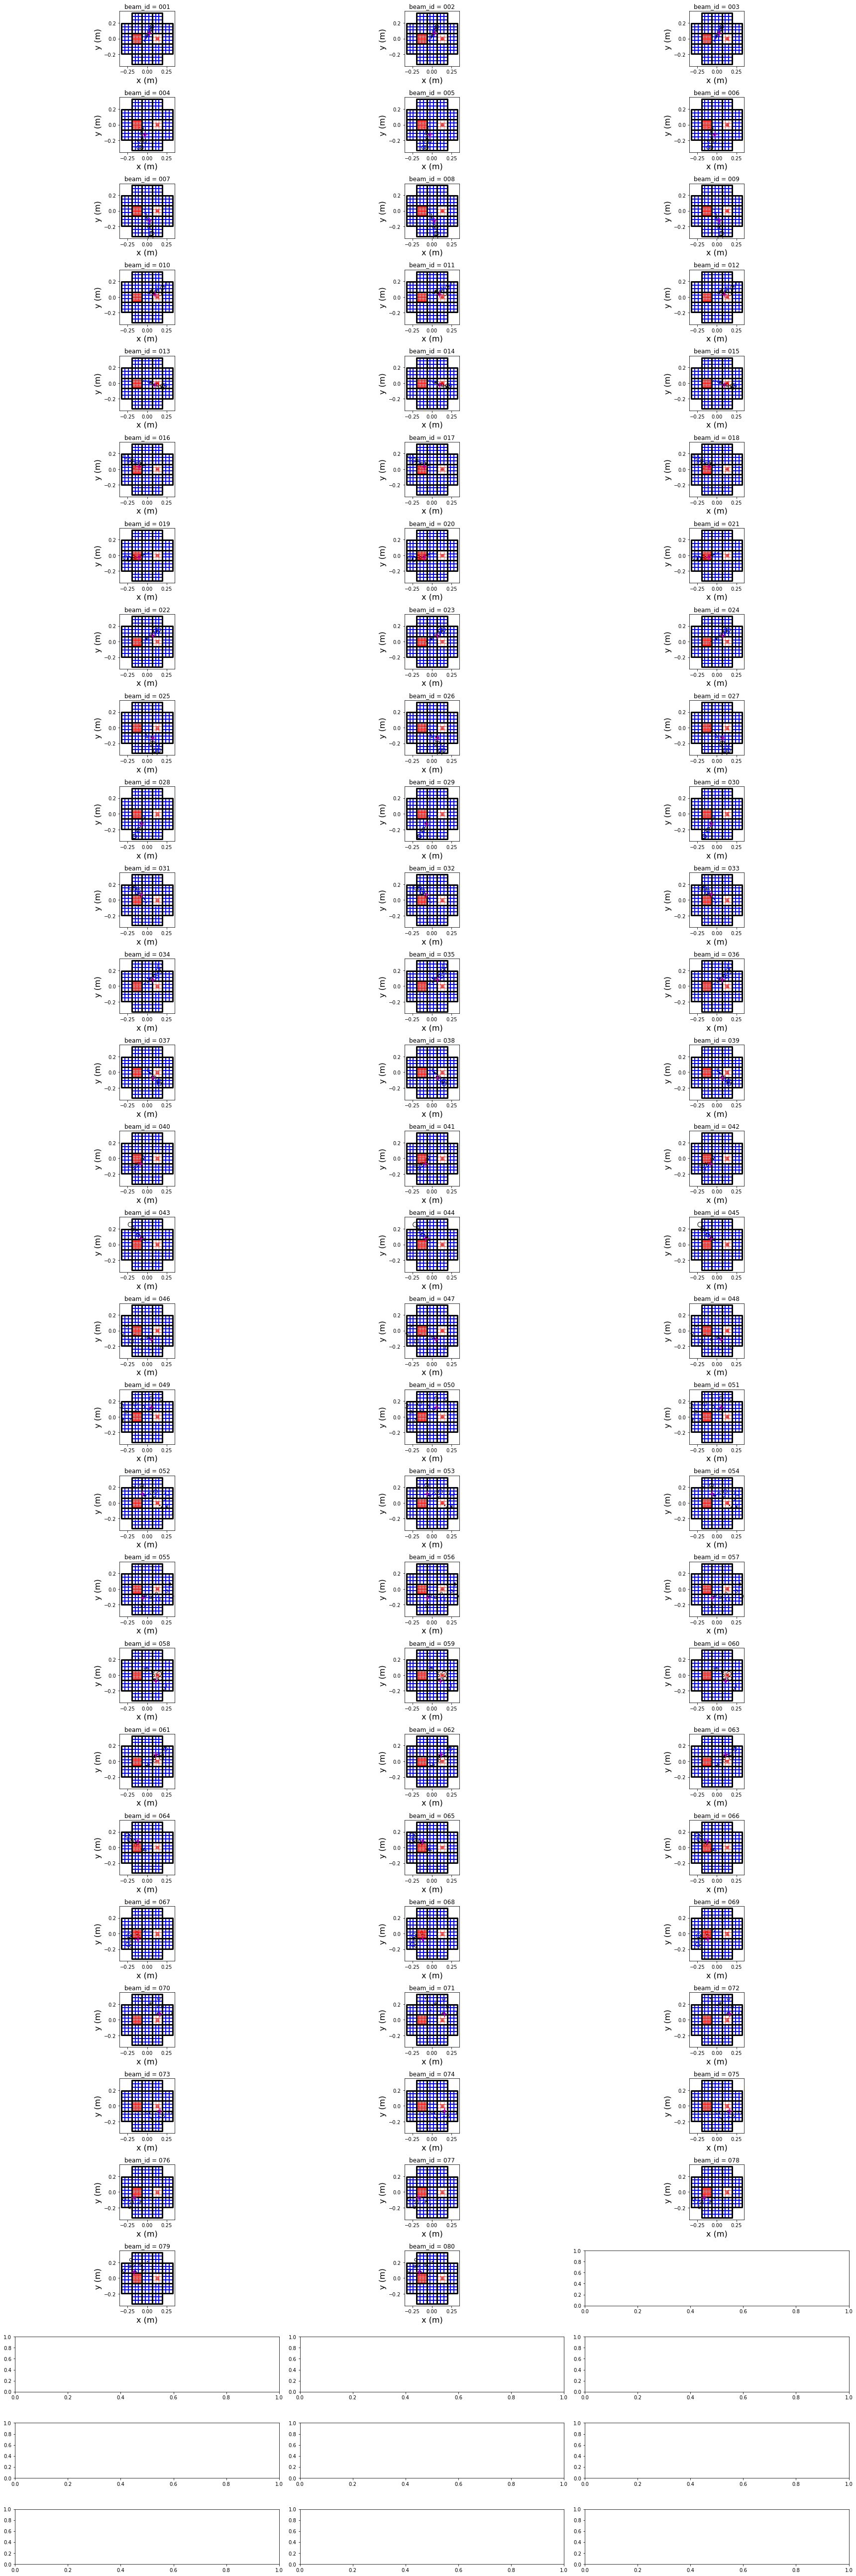

In [8]:
plt.rcParams["figure.figsize"] = [24, 72]
fig, ax = plt.subplots(30, 3)
axs = ax.flatten()
for i, id in enumerate(list(new_beam_frame['beam_id'])):
    conf = beam.to_dict((new_beam_frame[new_beam_frame['beam_id']==id]))
    try:
        simulate_ghost_config(telescope, conf, ax=axs[i])
    except:
        print("could not draw ", i)
plt.tight_layout()

## Build data frame of ghosts spots for all configurations

In [9]:
geom_id=312
spots_df_list = []
for i, id in enumerate(list(new_beam_frame['beam_id'])):
    conf = beam.to_dict((new_beam_frame[new_beam_frame['beam_id']==id]))
    print(conf['beam_id'])
    try:
        spots_df_list.append(simulator.run_and_analyze_simulation(telescope, geom_id, conf))
    except:
        print("\tUnable to simulate", conf['beam_id'])

20231121000001
20231121000002
20231121000003
20231121000004
20231121000005
20231121000006
20231121000007
20231121000008
20231121000009
20231121000010
20231121000011
20231121000012
20231121000013
20231121000014
20231121000015
20231121000016
20231121000017
20231121000018
20231121000019
20231121000020
20231121000021
20231121000022
20231121000023
20231121000024
20231121000025
20231121000026
20231121000027
20231121000028
20231121000029
20231121000030
20231121000031
20231121000032
20231121000033
20231121000034
20231121000035
20231121000036
20231121000037
20231121000038
20231121000039
20231121000040
20231121000041
20231121000042
20231121000043
20231121000044
20231121000045
20231121000046
20231121000047
20231121000048
20231121000049
20231121000050
20231121000051
20231121000052
20231121000053
20231121000054
20231121000055
20231121000056
20231121000057
20231121000058
20231121000059
20231121000060
20231121000061
20231121000062
20231121000063
20231121000064
20231121000065
20231121000066
2023112100

In [12]:
conf46 = new_beam_frame[new_beam_frame['beam_id']=="20231121000046"]
conf46

,beam_id,wl,n_photons,radius,x_offset,y_offset,z_offset,z_euler,y_euler,x_euler
20231121000046,20231121000046,5.000000e-07,100,0.00125,0.519617,-0.273911,3.076932,-110.954167,-19.172837,-6.425346


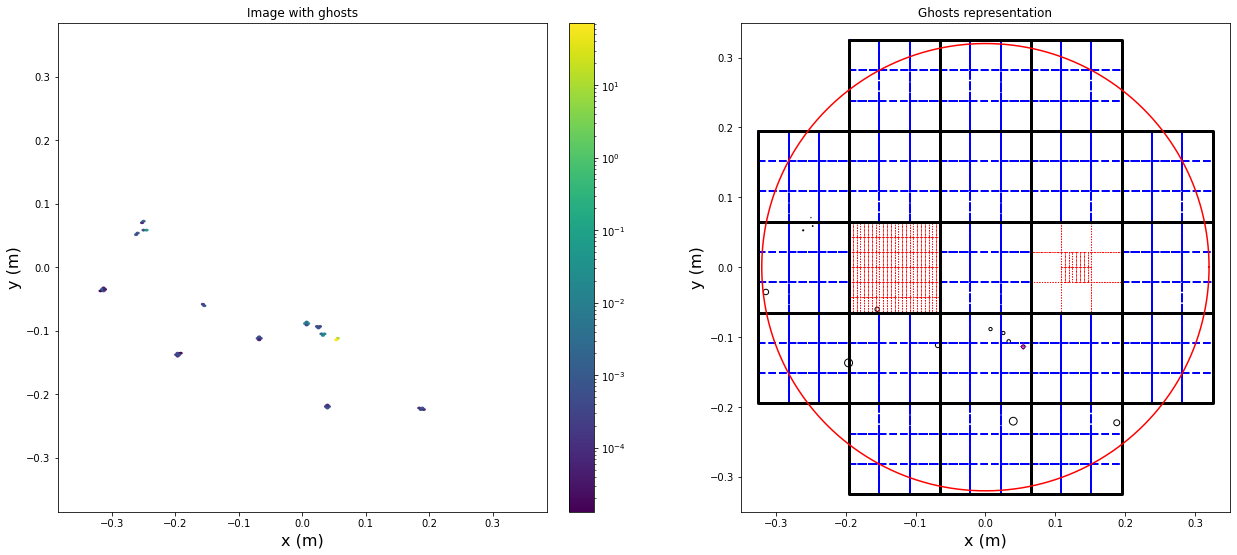

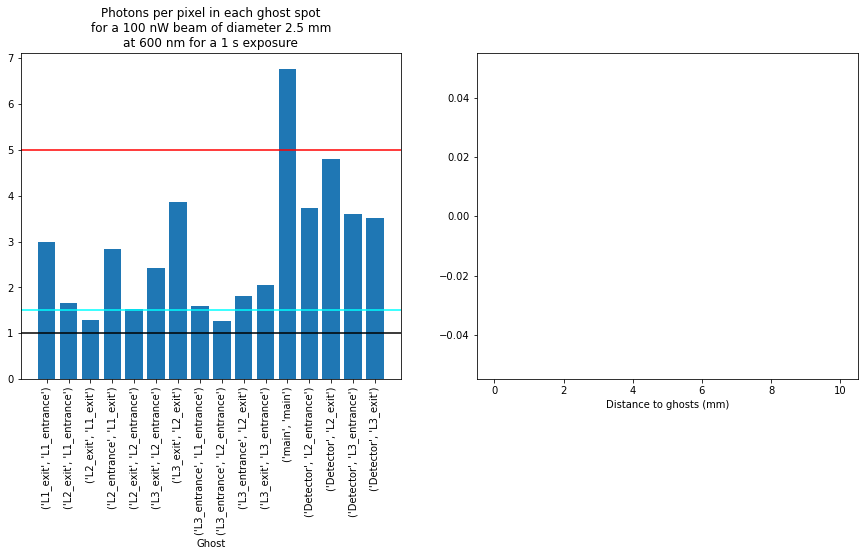

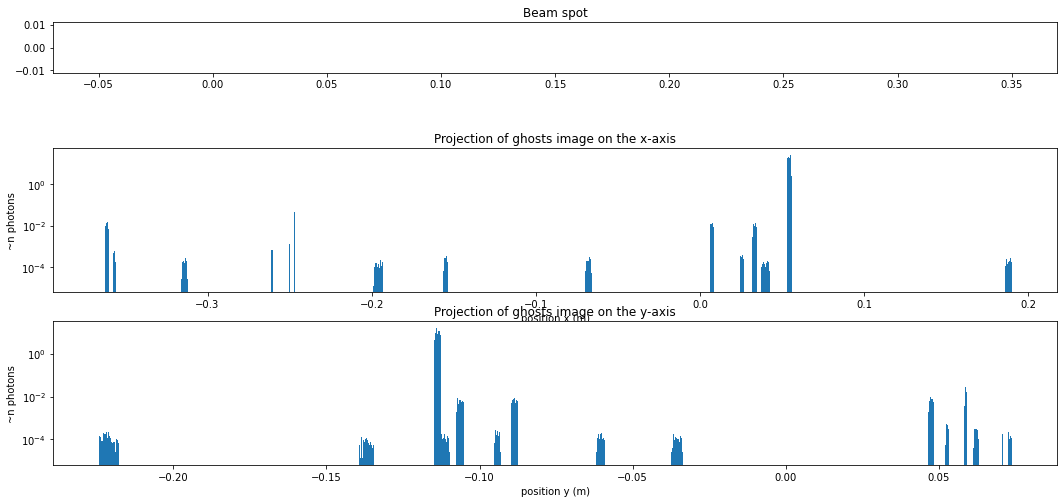

In [13]:

beam_test(telescope, beam.to_dict(conf46))

In [14]:
all_spots_df = pd.concat(spots_df_list)

In [15]:
all_spots_df.head()

,beam_id,geom_id,index,name,pos_x,std_x,pos_y,std_y,width_x,width_y,radius,radius_err,flux,surface,n_pixels,pixel_signal
0,20231121000001,312,0,"(L1_exit, L1_entrance)",0.001527,0.000273,0.023939,0.000273,0.001067,0.001040,0.000527,0.000014,0.001341,0.871975,7848,438.778106
1,20231121000001,312,1,"(L2_exit, L1_entrance)",0.035402,0.000877,0.094988,0.000877,0.003433,0.003342,0.001694,0.000045,0.001320,9.014651,81132,41.767417
2,20231121000001,312,2,"(L2_exit, L1_exit)",0.062956,0.001349,0.151116,0.001349,0.005280,0.005151,0.002608,0.000065,0.001331,21.365899,192293,17.764242
3,20231121000001,312,3,"(L2_entrance, L1_entrance)",-0.022450,0.000015,-0.012040,0.000015,0.000057,0.000054,0.000028,0.000002,0.001331,0.002403,22,157972.040688
4,20231121000001,312,4,"(L2_entrance, L1_exit)",-0.004275,0.000339,0.026042,0.000339,0.001328,0.001294,0.000656,0.000017,0.001341,1.350629,12156,283.278124


In [16]:
all_spots_df.tail()

,beam_id,geom_id,index,name,pos_x,std_x,pos_y,std_y,width_x,width_y,radius,radius_err,flux,surface,n_pixels,pixel_signal
14,20231121000080,312,14,"(Detector, L1_exit)",0.004697,0.000221,0.211479,0.000221,0.000894,0.000811,0.000426,0.000042,0.045896,0.570676,5136,22942.104240
15,20231121000080,312,15,"(Detector, L2_entrance)",-0.094633,0.000494,0.175878,0.000494,0.001992,0.001837,0.000957,0.000077,0.046265,2.878997,25911,4584.194446
16,20231121000080,312,16,"(Detector, L2_exit)",-0.020943,0.000174,0.100169,0.000174,0.000702,0.000659,0.000340,0.000021,0.046637,0.363629,3273,36587.020499
17,20231121000080,312,17,"(Detector, L3_entrance)",-0.146705,0.000555,0.079789,0.000555,0.002239,0.002035,0.001069,0.000102,0.047013,3.587861,32291,3737.930179
18,20231121000080,312,18,"(Detector, L3_exit)",-0.163276,0.000605,0.080250,0.000605,0.002438,0.002232,0.001167,0.000103,0.047391,4.281838,38537,3157.315052


In [18]:
all_spots_df.to_parquet("run_13579_simulated_beam_spots_v1.parquet")

In [31]:
a = [new_beam_frame.iloc[i] for i in range(2, 12, 3)]

In [32]:
a

[beam_id      20231121000003
 wl                      0.0
 n_photons               100
 radius              0.00125
 x_offset           0.057653
 y_offset           0.086561
 z_offset            3.06805
 z_euler               -90.0
 y_euler            -1.15959
 x_euler                 0.7
 Name: 20231121000003, dtype: object,
 beam_id      20231121000006
 wl                      0.0
 n_photons               100
 radius              0.00125
 x_offset           0.048128
 y_offset          -0.113435
 z_offset           3.069689
 z_euler               -90.0
 y_euler            -3.15959
 x_euler                 0.7
 Name: 20231121000006, dtype: object,
 beam_id      20231121000009
 wl                      0.0
 n_photons               100
 radius              0.00125
 x_offset           0.057616
 y_offset          -0.113421
 z_offset           3.069806
 z_euler               -90.0
 y_euler            -1.15959
 x_euler                 0.7
 Name: 20231121000009, dtype: object,
 beam_id      20